
# Binomial Distribution: Coin-Toss Example

Suppose we toss a coin \(N\) times.

For each toss,

$$
P(H)=p, \qquad P(T)=q,
$$

with

$$
p+q=1.
$$

Define the random variable

$$
X=\text{number of heads in }N\text{ tosses}.
$$

Then

$$
X\sim \mathrm{Binomial}(N,p),
$$

and

$$
P(X=k)
=
\binom{N}{k}p^k q^{N-k},
\qquad k=0,1,\ldots,N.
$$

In this notebook, change only the values of **\(N\), \(p\), and \(q\)** and rerun the cells.


## 1. Choose the coin and number of tosses

In [19]:
import numpy as np
import matplotlib.pyplot as plt
# Try changing these three numbers
N = 100       # number of tosses
p = 0.5      # probability of Heads
q = 0.5     # probability of Tails

print("N =", N)
print("p =", p)
print("q =", q)
print("p + q =", p + q)

N = 100
p = 0.5
q = 0.5
p + q = 1.0



For a valid coin model we must have

$$
p+q=1.
$$

The next cell checks this.


In [20]:
if abs(p + q - 1) < 1e-12:
    print("Good: p + q = 1")
else:
    print("Please choose p and q so that p + q = 1")

Good: p + q = 1


## 2. Compute the binomial probabilities

In [21]:
import math

# Possible values of X
k_values = list(range(N + 1)) # Sample-space \Omega

# Compute P(X = k) for each k
pmf = []

for k in k_values:
    number_of_sequences = math.comb(N, k)
    probability_one_sequence = (p ** k) * (q ** (N - k))
    probability = number_of_sequences * probability_one_sequence

    pmf.append(probability)

#pmf

## 3. Plot the probability mass function (PMF)

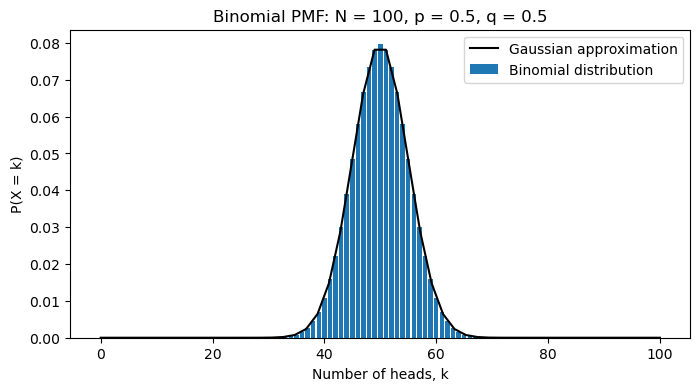

In [22]:
def Gauss(x,mu,sig):
    den = np.sqrt(2*np.pi)*sig 
    num = np.exp( -((x - mu)**2)/(2* (sig**2)) )
    return num/den

x_ = np.linspace(0,N)

plt.figure(figsize=(8, 4))

plt.plot(x_, Gauss(x_,N*p,np.sqrt(N*p*q)),color='black',label='Gaussian approximation')
plt.bar(k_values, pmf,label='Binomial distribution')
plt.legend(loc='best')


plt.xlabel("Number of heads, k")
plt.ylabel("P(X = k)")
plt.title(f"Binomial PMF: N = {N}, p = {p}, q = {q}")
#plt.xticks(k_values)
plt.show()

## Normalization check

In [23]:
np.sum(pmf) # the area under the curve ~ adding all the bins height together

1.0


The height of the bar at \(k\) is

$$
P(X=k).
$$

The probabilities must sum to one.

$$
\sum_{k \in \Omega} P(X=k) = 1
$$





In [24]:
total_probability = sum(pmf)
print("Sum of all probabilities =", total_probability)

Sum of all probabilities = 1.0000000000000002


## 4. Compute the cumulative distribution function (CDF)


The CDF is

$$
F(k)=P(X\le k).
$$

For a discrete random variable $X$,

$$
F(k)
=
P(X=0)+P(X=1)+\cdots+P(X=k).
$$


In [25]:
cdf = []
running_total = 0
for probability in pmf:
    running_total = running_total + probability
    cdf.append(running_total)

## 5. Plot the CDF

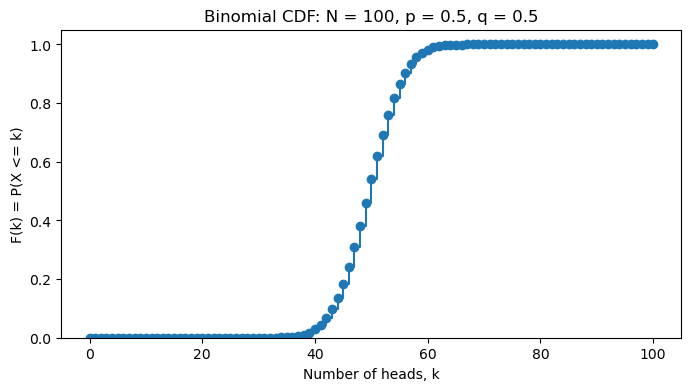

In [26]:
plt.figure(figsize=(8, 4))

plt.step(k_values, cdf, where="post")
plt.scatter(k_values, cdf)

plt.xlabel("Number of heads, k")
plt.ylabel("F(k) = P(X <= k)")
plt.title(f"Binomial CDF: N = {N}, p = {p}, q = {q}")
#plt.xticks(k_values)
plt.ylim(0, 1.05)

plt.show()

Because $X$ is discrete, the CDF is a **step function**.

The size of the jump at $k$ is exactly
$$
P(X=k).
$$

## 6. Mean and variance


For a binomial random variable,

$$
E[X]=Np,
$$

and

$$
\operatorname{Var}(X)=Npq=Np(1-p).
$$

The standard deviation is

$$
\sigma_X=\sqrt{Npq}.
$$


In [27]:
mean = N * p
variance = N * p * q
standard_deviation = variance ** 0.5

print("Mean =", mean)
print("Variance =", variance)
print("Standard deviation =", standard_deviation)

Mean = 50.0
Variance = 25.0
Standard deviation = 5.0


## 7. Try different coins


Try rerunning the notebook with:

### Fair coin
```python
N = 10
p = 0.5
q = 0.5
```

### Coin biased toward heads
```python
N = 10
p = 0.8
q = 0.2
```

### More tosses
```python
N = 30
p = 0.5
q = 0.5
```

Questions to think about:

1. Where is the PMF centered?
2. What happens to the shape when \(p\neq q\)?
3. What happens to the variance of the distribution when $p$ is small ?
4. What happens as \(N\) becomes larger?
5. Why does the CDF always increase?
6. Why does the final CDF value equal 1\)?
